# Axial trio (DIAGONALLY-n-SUMMED, normalized currents): loc vs disp vs exact — deterministic, lattice prop, $L=1,2,4$

Axial sibling of `comp_trio_jj_claude.ipynb`.  The exact axial is Eq.(3.55):
$$
C_{A+-,c}(t_0\to t)=\mathrm{tr}\big[K(t_0)(1-D_\text{ov}^\dagger)D_\text{ov}^{-\dagger}K^\dagger(t)(1-D_\text{ov})D_\text{ov}^{-1}\big];
$$
loc/disp "replace $K\to\sigma$ (or $W_d$) and rip off $(1-D_\text{ov})$" — same as the vector loc/disp but with the $t_0$-leg propagator $P\to P^\dagger$ and the sink kernel daggered.

Single complex channel `Apm` ($C_{A+-}$ is NOT self-reflection-even; it reflects to $C_{A-+}$, Eq.3.57).  Plot $\mathrm{Re}$ as the signal; $\mathrm{Im}$ carried as a diagnostic.

Loaders: $G_t=$`tp`(or `s3`); $G_s=$`sp` for disp/exact, $(s_1{+}s_2)/(D{-}1)$ for loc (loc sums both spatial Pauli channels).  Weight = area, $1/(4\pi)$ folded by `write_corr_axial`.

**CFT anchor (free theory):** axial $=$ vector ($C_J^A=C_J^V$), so naively $\mathrm{Re}\,G^s_A/\mathrm{Re}\,G^t_A\to-1$ and the same ylm rates ($e^{-2t},e^{-3t}$, ratio $2.4$).  The references below are the vector shapes; the data reveals whether the axial follows them.

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

dir1 = '/mnt/barracuda22/qed3/qed3/src/both_3d/'
ESN  = dir1 + 'data_free_vmRe0.000000vmIm0.000000/'
at_cft = 0.2
Nt_cft = 128
Delta_cft = 2.0
Dm1 = 2.0   # D - 1 : ONLY for loc (which sums BOTH spatial Pauli channels s1+s2 = D-1 directions).
tag = ''    # '' = lattice prop ; 'cont_' = continuum prop

def cft_shape(t):
    return np.exp(-Delta_cft*t) * (1.0 - np.exp(-t))**(-2.0*Delta_cft)

def load_Apm(corrdir, proj, origin='t0_0', k=0):
    path = ESN + corrdir + '/corr.' + str(k) + '.h5'
    with h5py.File(path, 'r') as f:
        key = 'h0/' + origin + '/' + proj + '/Apm'
        return f[key+'/real'][()] + 1j*f[key+'/imag'][()]

# DIAGONALLY-n-SUMMED, normalized currents (Eq.4.29: area weight + 1/4pi, kappa absorbed in J_norm).
# Per-direction G^s (Eq.4.28) -> G_s/G_t = -1:
#   loc  sums s1+s2 (BOTH transverse Pauli channels = D-1 dirs) -> divide by Dm1.
#   disp/exact are LINK currents: the diagonal <j_e j_e> on one link IS the single per-direction value g
#     (e is a unit vector, <j^a j^b> = g delta^ab), and the area-weighted link sum averages to g -- it does
#     NOT pick up a factor (D-1).  So NO division (they are already per-direction, -1 raw).
def loc_Gt(L):  cd='corr_deter_local_axial_%sL%d'%(tag,L); return load_Apm(cd,'s3').real
def loc_Gs(L):  cd='corr_deter_local_axial_%sL%d'%(tag,L); return ((load_Apm(cd,'s1')+load_Apm(cd,'s2'))/Dm1).real
def disp_Gt(L): return load_Apm('corr_deter_disp_axial_%sL%d'%(tag,L),'tp').real
def disp_Gs(L): return load_Apm('corr_deter_disp_axial_%sL%d'%(tag,L),'sp').real
def ex_Gt(L):   return load_Apm('corr_deter_exact1_axial_%sL%d'%(tag,L),'tp').real
def ex_Gs(L):   return load_Apm('corr_deter_exact1_axial_%sL%d'%(tag,L),'sp').real

L      c_loc           c_disp          c_exact           (sign(c) = lattice Gt sign)
L=1     1.509e+03       1.509e+03       6.251e+04     
L=2     4.158e+03       4.158e+03       6.449e+04     
L=4     1.669e+04       1.669e+04         --          


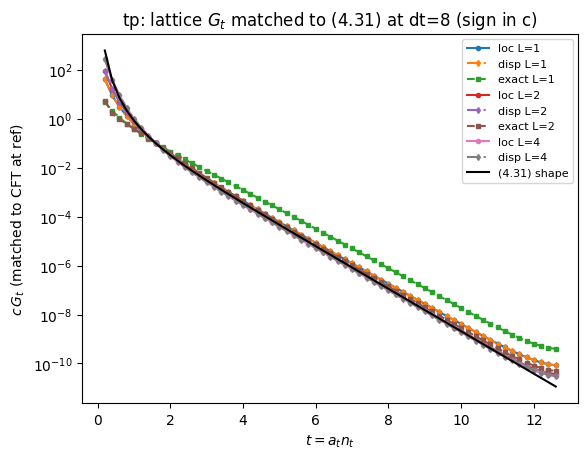

In [2]:
# tp (G_t): normalize each estimator by c_e = cft_shape(t_ref)/Gt_e(t_ref) -- a SINGLE constant per
# estimator matching the lattice tp to the analytic (4.31) shape at the reference (ref=8 = your "t=8",
# i.e. dt index 8, t=1.6).  sign(c_e) IS the lattice Gt sign (printed below).  c_e*Gt_e then overlays the
# +cft_shape by construction; log axis is positive via the CFT match (no per-curve sign flips).
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 8
plt.figure()
print('%-6s %-15s %-15s %-15s   (sign(c) = lattice Gt sign)' % ('L','c_loc','c_disp','c_exact'))
for L in [1, 2, 4]:
    row = []
    for nm, f, mk in [('loc', loc_Gt, 'o-'), ('disp', disp_Gt, 'd-.'), ('exact', ex_Gt, 's--')]:
        try:
            g = f(L); c = cft_shape(t[ref-1]) / g[ref]
            plt.plot(t, c*g[dt], mk, ms=3, label='%s L=%d' % (nm, L))
            row.append('% .3e' % c)
        except (OSError, KeyError):
            row.append('   --        ')
    print('L=%-4d %-15s %-15s %-15s' % (L, *row))
plt.plot(t, cft_shape(t), 'k-', label='(4.31) shape')
plt.yscale('log'); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$c\,G_t$ (matched to CFT at ref)')
plt.title('tp: lattice $G_t$ matched to (4.31) at dt=%d (sign in c)' % ref); plt.legend(fontsize=8)
plt.savefig('comp_trio_axial_sum_tp.pdf', bbox_inches='tight')

<>:14: SyntaxWarning: invalid escape sequence '\,'
<>:16: SyntaxWarning: invalid escape sequence '\,'
<>:14: SyntaxWarning: invalid escape sequence '\,'
<>:16: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_709799/2688228239.py:14: SyntaxWarning: invalid escape sequence '\,'
  plt.plot(t, cft_shape(t), 'k-', label='(4.28) shape (= $-c\,G_s$ if ratio $-1$)')
/tmp/ipykernel_709799/2688228239.py:16: SyntaxWarning: invalid escape sequence '\,'
  plt.title('sp: $-c\,G_s$ with the tp constant; wrong-sign $G_s$ falls off the log axis'); plt.legend(fontsize=8)


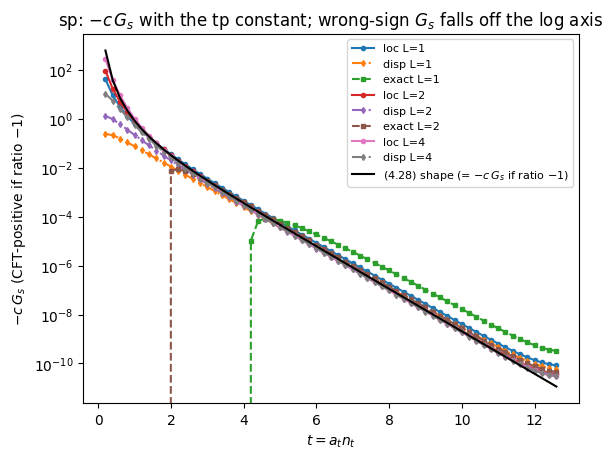

In [3]:
# sp (G_s): use the SAME c_e (from tp at ref) to normalize Gs -> c_e*Gs_e carries the PHYSICAL sign
# relative to Gt.  CFT predicts Gs = -Gt (ratio -1), so the CFT-positive combination is -c_e*Gs_e; plot THAT
# on log.  loc/disp (Gs opposite sign to Gt) -> positive, track +cft_shape.  A wrong-sign Gs (e.g. exact sp,
# which came out the SAME sign as Gt) gives -c_e*Gs_e < 0 -> it DROPS OFF the log axis -- shown honestly.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 8
plt.figure()
for L in [1, 2, 4]:
    for nm, fg, ft, mk in [('loc', loc_Gs, loc_Gt, 'o-'), ('disp', disp_Gs, disp_Gt, 'd-.'), ('exact', ex_Gs, ex_Gt, 's--')]:
        try:
            gs = fg(L); gt = ft(L); c = cft_shape(t[ref-1]) / gt[ref]   # SAME c as tp
            plt.plot(t, -c*gs[dt], mk, ms=3, label='%s L=%d' % (nm, L))
        except (OSError, KeyError):
            pass
plt.plot(t, cft_shape(t), 'k-', label='(4.28) shape (= $-c\,G_s$ if ratio $-1$)')
plt.yscale('log'); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$-c\,G_s$ (CFT-positive if ratio $-1$)')
plt.title('sp: $-c\,G_s$ with the tp constant; wrong-sign $G_s$ falls off the log axis'); plt.legend(fontsize=8)
plt.savefig('comp_trio_axial_sum_sp.pdf', bbox_inches='tight')

In [4]:
# SIGN + magnitude table at dt=5 (summed, normalized; area + 1/4pi).  tp<0, sp>0 expected.
print('%-6s %-13s %-13s %-13s | %-15s %-13s %-13s' % (
    'L','loc_Gt(s3)','disp_tp','exact_tp','loc_Gs(s1+s2)','disp_sp','exact_sp'))
for L in [1, 2, 4]:
    def g(f):
        try: return '% .3e' % f(L)[5]
        except (OSError, KeyError): return '   --      '
    print('L=%-4d %-13s %-13s %-13s | %-15s %-13s %-13s' % (
        L, g(loc_Gt), g(disp_Gt), g(ex_Gt), g(loc_Gs), g(disp_Gs), g(ex_Gs)))
print('\n(All three are the area-weighted Eq.(4.29) sums of normalized currents.  tp<0, sp>0; the')
print(' magnitudes share the continuum C_J up to each operator s lattice Z + (exact) GW dressing.)')

L      loc_Gt(s3)    disp_tp       exact_tp      | loc_Gs(s1+s2)   disp_sp       exact_sp     
L=1     4.130e-04     4.130e-04     6.080e-06    | -4.130e-04      -4.990e-05     2.964e-05   
L=2     1.896e-04     1.896e-04     6.236e-06    | -1.896e-04      -5.286e-05     1.295e-05   
L=4     6.132e-05     6.132e-05       --         | -6.132e-05      -3.346e-05       --        

(All three are the area-weighted Eq.(4.29) sums of normalized currents.  tp<0, sp>0; the
 magnitudes share the continuum C_J up to each operator s lattice Z + (exact) GW dressing.)


L      loc Gs/Gt        disp Gs/Gt       exact Gs/Gt     
L=1    -1.0000          -0.2381           3.6407         
L=2    -1.0000          -0.5037           0.2951         
L=4    -1.0000          -0.8012             --           


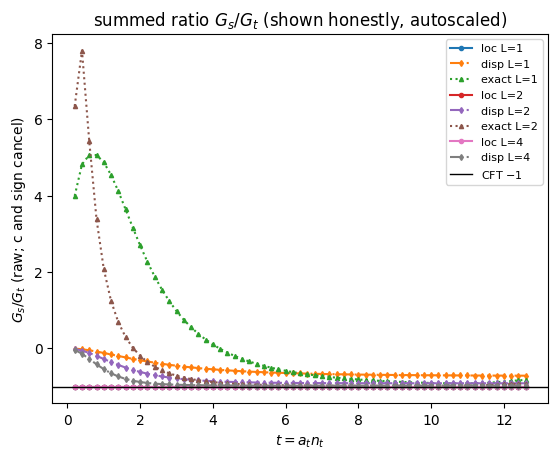

In [5]:
# RATIO G_s/G_t: the normalization c cancels (same c for tp and sp), leaving the PHYSICAL ratio WITH its
# sign.  loc -> -1 exactly; disp -> -1 from above with L (point-split spatial -> on-site, discretization);
# exact is awkward (the GW sp sign) -- shown honestly, autoscaled, NOT clipped.  CFT target -1.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 8
plt.figure()
print('%-6s %-16s %-16s %-16s' % ('L', 'loc Gs/Gt', 'disp Gs/Gt', 'exact Gs/Gt'))
for L in [1, 2, 4]:
    row = []
    for nm, fg, ft, mk in [('loc', loc_Gs, loc_Gt, 'o-'), ('disp', disp_Gs, disp_Gt, 'd-.'), ('exact', ex_Gs, ex_Gt, '^:')]:
        try:
            r = fg(L) / ft(L); plt.plot(t, r[dt], mk, ms=3, label='%s L=%d' % (nm, L)); row.append('% .4f' % r[ref])
        except (OSError, KeyError):
            row.append('   --   ')
    print('L=%-4d %-16s %-16s %-16s' % (L, *row))
plt.axhline(-1.0, color='k', lw=1, label=r'CFT $-1$')
plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$G_s/G_t$ (raw; c and sign cancel)')
plt.title('summed ratio $G_s/G_t$ (shown honestly, autoscaled)'); plt.legend(fontsize=8)
plt.savefig('comp_trio_axial_sum_ratio.pdf', bbox_inches='tight')

## Ylm tower — Eq.(4.36) (qed3int_v2-13)

$Y_{\ell m}$-projected **temporal** current (descendants of $G^t$):
$$
g_\ell(t)=\frac{1}{2\ell+1}\sum_m \mathrm{tr}[\Sigma_{\ell m}(t_0)\,P\,\Sigma_{\ell m}(t)\,P],
\qquad \Sigma_{\ell m}=\sum_n A_n Y_{\ell m}(\hat n)\,J^t_{\rm norm}(n),\ A_n=\texttt{dual\_areas}.
$$
- **loc** (`corr_deter_local`, key `ylm/l{0,1,2}`): $J^t_{\rm norm}=\sigma_3$ on-site. (already produced)
- **disp** (`corr_deter_disp`): $J^t_{\rm norm}=W^t_d=C^t/\kappa_t$ (temporal link). (rerun `tmp_summed_fast` to produce)
- **exact** (`corr_deter_exactsum`): $J^t_{\rm norm}=K^t/\kappa_t$ (overlap conserved). (rerun `--sum` with the ylm-augmented binary)

CFT tower (Eq.4.36): $g_1\to -\tfrac13 C_j e^{-2t}$, $g_2\to -\tfrac45 C_j e^{-3t}$, $g_0\to 0$ (charge conservation;
on the icosahedron $\ell=0$ leaks only at $\ell=6$).  Convention-free checks: decay rates $(2,3)$;
ratio $g_2 e^{3t}/g_1 e^{2t}\to \tfrac{4/5}{1/3}=\tfrac{12}{5}=2.4$; $g_0/g_1\to0$.

In [6]:
# NOTE: exact uses the SINGLE-insertion exact1 (--ins 0); at L=1 (vertex/edge-transitive
# icosahedron) one insertion == the diagonal sum for tp/sp/ratio.  exact1 has NO ylm tower
# (that is a --sum-only object), so the ylm cells below show loc/disp and skip exact (try/except).
# Ylm loaders (Eq.4.36): g_l from h0/t0_0/ylm/l{0,1,2}/Apm.  No 1/(D-1) here (this is the temporal tower).
def loc_gl(L, l):  return load_Apm('corr_deter_local_axial_%sL%d'%(tag,L),   'ylm/l%d'%l).real
def disp_gl(L, l): return load_Apm('corr_deter_disp_axial_%sL%d'%(tag,L),    'ylm/l%d'%l).real
def ex_gl(L, l):   return load_Apm('corr_deter_exact1_axial_%sL%d'%(tag,L),'ylm/l%d'%l).real
YOPS = [('loc', loc_gl, 'o-'), ('disp', disp_gl, 'd-.'), ('exact', ex_gl, 's--')]

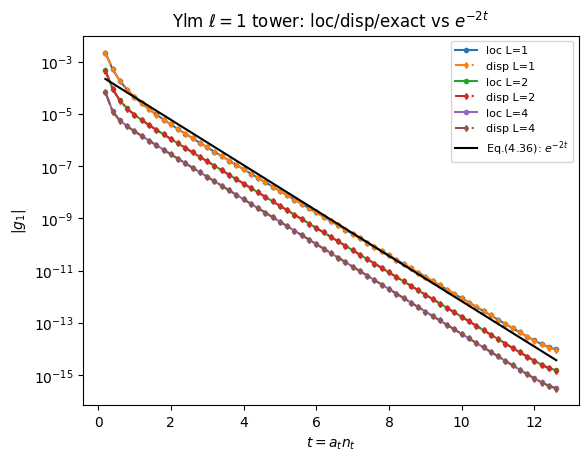

In [7]:
# ell=1 tower: -g_1 (loc/disp/exact) vs e^{-2t}, L=1,2.  |.| log; reference anchored to loc L=1.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 5
plt.figure()
for L in [1, 2, 4]:
    for name, f, mk in YOPS:
        try:
            g = f(L, 1)
            plt.plot(t, np.abs(g[dt]), mk, ms=3, label='%s L=%d' % (name, L))
        except (OSError, KeyError):
            pass
try:
    g = loc_gl(1, 1); A = np.abs(g[ref]) / np.exp(-2.0*t[ref-1])
    plt.plot(t, A*np.exp(-2.0*t), 'k-', label=r'Eq.(4.36): $e^{-2t}$')
except (OSError, KeyError):
    pass
plt.yscale('log'); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$|g_1|$')
plt.title(r'Ylm $\ell=1$ tower: loc/disp/exact vs $e^{-2t}$'); plt.legend(fontsize=8)
plt.savefig('comp_trio_ylm_l1.pdf', bbox_inches='tight')

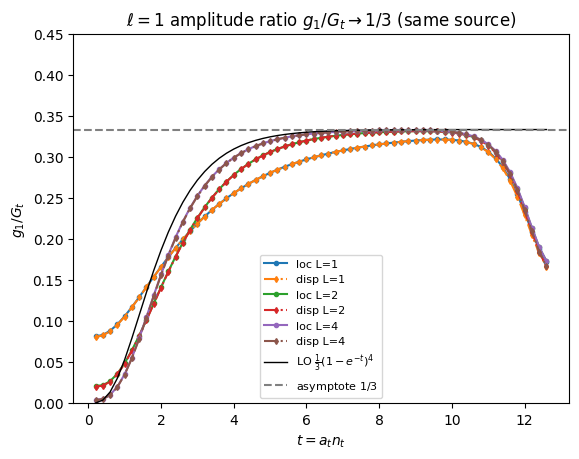

In [8]:
# ell=1 AMPLITUDE ratio g_1 / G_t (SAME source type), loc/disp/exact, L=1,2.
# CFT: g_1 -> -1/3 C_j e^{-2t} (Eq.4.36) and G_t -> -C_j e^{-2t}(1-e^{-t})^{-4} (Eq.4.31), so C_j cancels:
#   g_1/G_t -> 1/3 at large t; to leading order g_1/G_t = (1/3)(1-e^{-t})^4 (the small-t block bend).
# G_t = loc s3 / disp tp / exact tp (the temporal correlator, NOT the /(D-1) spatial).
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft
GT = {'loc': loc_Gt, 'disp': disp_Gt, 'exact': ex_Gt}
plt.figure()
for L in [1, 2, 4]:
    for name, f, mk in YOPS:
        try:
            g1 = f(L, 1); gt = GT[name](L)
            plt.plot(t, g1[dt]/gt[dt], mk, ms=3, label='%s L=%d' % (name, L))
        except (OSError, KeyError):
            pass
plt.plot(t, (1.0/3.0)*(1.0-np.exp(-t))**4, 'k-', lw=1, label=r'LO $\frac{1}{3}(1-e^{-t})^4$')
plt.axhline(1.0/3.0, color='gray', ls='dashed', label=r'asymptote $1/3$')
plt.ylim(0, 0.45); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$g_1 / G_t$')
plt.title(r'$\ell=1$ amplitude ratio $g_1/G_t\to 1/3$ (same source)'); plt.legend(fontsize=8)
plt.savefig('comp_trio_ylm_g1_over_Gt.pdf', bbox_inches='tight')

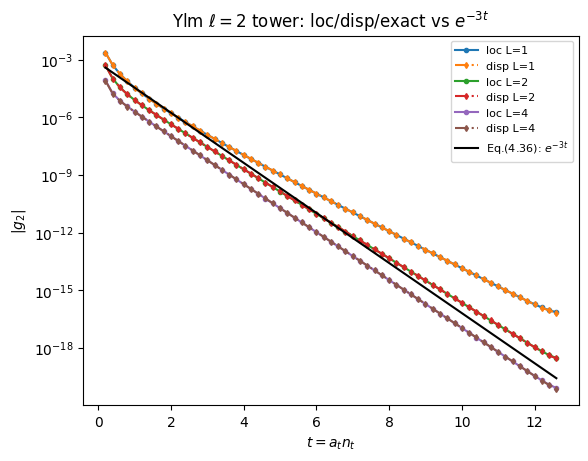

In [9]:
# ell=2 tower: -g_2 (loc/disp/exact) vs e^{-3t}, L=1,2.  |.| log; reference anchored to loc L=1.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 5
plt.figure()
for L in [1, 2, 4]:
    for name, f, mk in YOPS:
        try:
            g = f(L, 2)
            plt.plot(t, np.abs(g[dt]), mk, ms=3, label='%s L=%d' % (name, L))
        except (OSError, KeyError):
            pass
try:
    g = loc_gl(1, 2); A = np.abs(g[ref]) / np.exp(-3.0*t[ref-1])
    plt.plot(t, A*np.exp(-3.0*t), 'k-', label=r'Eq.(4.36): $e^{-3t}$')
except (OSError, KeyError):
    pass
plt.yscale('log'); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$|g_2|$')
plt.title(r'Ylm $\ell=2$ tower: loc/disp/exact vs $e^{-3t}$'); plt.legend(fontsize=8)
plt.savefig('comp_trio_ylm_l2.pdf', bbox_inches='tight')

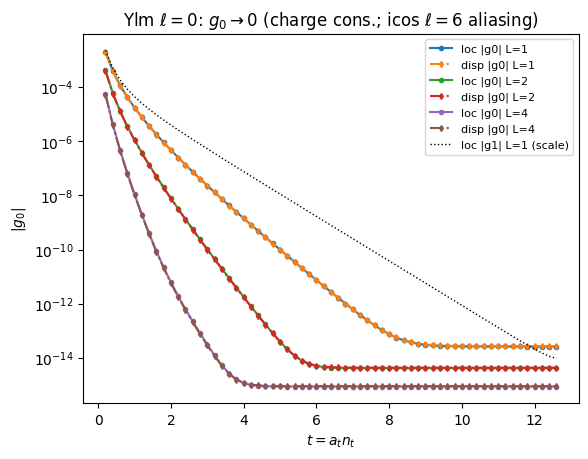

In [10]:
# ell=0 mode: |g_0| (loc/disp/exact, L=1,2).  CFT: g0 -> 0 (charge conservation, Q|0>=0).  On the
# icosahedron (spherical 5-design) it leaks only at l=6, so |g0| ~ E_6^2 (shrinks ~1/L^4 with L, fixed
# rate e^{-7t}) -- a tiny vanishing mode, far below g1.  |.| used since this null mode has no physical sign.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 5
plt.figure()
for L in [1, 2, 4]:
    for name, f, mk in YOPS:
        try:
            g0 = f(L, 0)
            plt.plot(t, np.abs(g0[dt]), mk, ms=3, label='%s |g0| L=%d' % (name, L))
        except (OSError, KeyError):
            pass
try:  # loc |g1| L=1 as a scale reference: g0 should sit well below the l=1 tower
    g1 = loc_gl(1, 1); plt.plot(t, np.abs(g1[dt]), 'k:', lw=1, label='loc |g1| L=1 (scale)')
except (OSError, KeyError):
    pass
plt.yscale('log'); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$|g_0|$')
plt.title(r'Ylm $\ell=0$: $g_0\to 0$ (charge cons.; icos $\ell=6$ aliasing)'); plt.legend(fontsize=8)
plt.savefig('comp_trio_ylm_l0.pdf', bbox_inches='tight')

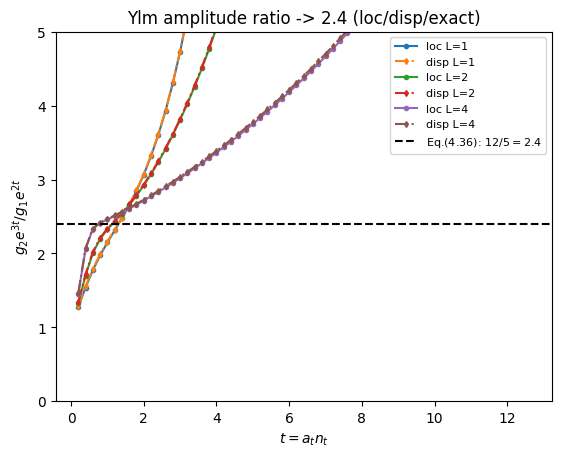

In [11]:
# Ylm amplitude ratio g_2 e^{3t} / g_1 e^{2t} -> 12/5 = 2.4 (Eq.4.36), loc/disp/exact, L=1,2.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft
plt.figure()
for L in [1, 2, 4]:
    for name, f, mk in YOPS:
        try:
            g1 = f(L, 1); g2 = f(L, 2)
            plt.plot(t, (g2[dt]*np.exp(3.0*t))/(g1[dt]*np.exp(2.0*t)), mk, ms=3, label='%s L=%d' % (name, L))
        except (OSError, KeyError):
            pass
plt.axhline(12.0/5.0, color='k', ls='dashed', label=r'Eq.(4.36): $12/5=2.4$')
plt.ylim(0, 5); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$g_2 e^{3t}/g_1 e^{2t}$')
plt.title('Ylm amplitude ratio -> 2.4 (loc/disp/exact)'); plt.legend(fontsize=8)
plt.savefig('comp_trio_ylm_ratio.pdf', bbox_inches='tight')

In [12]:
# Ylm convention-free checks (print): effective decay rates -> (2,3); g_2 e^{3t}/g_1 e^{2t} -> 2.4; g0/g1 -> 0.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft
def eff_rate(g):  # m_eff(t) = -(1/at) log( g[n+1]/g[n] ), mid-t window
    gg = g[dt]; return -np.log(gg[1:]/gg[:-1]) / at_cft
print('predicted: l=1 rate 2.0, l=2 rate 3.0, ratio 2.4, g0/g1 -> 0')
for L in [1, 2, 4]:
    for name, f, _ in YOPS:
        try:
            g0 = f(L,0); g1 = f(L,1); g2 = f(L,2)
            r1 = np.round(np.mean(eff_rate(g1)[14:20]), 3)
            r2 = np.round(np.mean(eff_rate(g2)[14:20]), 3)
            rat = np.round(np.mean(((g2[dt]*np.exp(3*t))/(g1[dt]*np.exp(2*t)))[12:20]), 3)
            g0g1 = np.round((g0[dt]/g1[dt])[5], 5)
            print('%-6s L=%d: rate(l1)=%s rate(l2)=%s  ratio=%s  g0/g1[5]=%s' % (name, L, r1, r2, rat, g0g1))
        except (OSError, KeyError):
            print('%-6s L=%d: missing' % (name, L))

predicted: l=1 rate 2.0, l=2 rate 3.0, ratio 2.4, g0/g1 -> 0
loc    L=1: rate(l1)=1.932 rate(l2)=2.41  ratio=5.672  g0/g1[5]=0.30695
disp   L=1: rate(l1)=1.932 rate(l2)=2.41  ratio=5.683  g0/g1[5]=0.30323
exact  L=1: missing
loc    L=2: rate(l1)=1.961 rate(l2)=2.677  ratio=4.18  g0/g1[5]=0.06479
disp   L=2: rate(l1)=1.96 rate(l2)=2.677  ratio=4.196  g0/g1[5]=0.06319
exact  L=2: missing
loc    L=4: rate(l1)=1.981 rate(l2)=2.872  ratio=3.123  g0/g1[5]=0.00137
disp   L=4: rate(l1)=1.98 rate(l2)=2.87  ratio=3.143  g0/g1[5]=0.00131
exact  L=4: missing


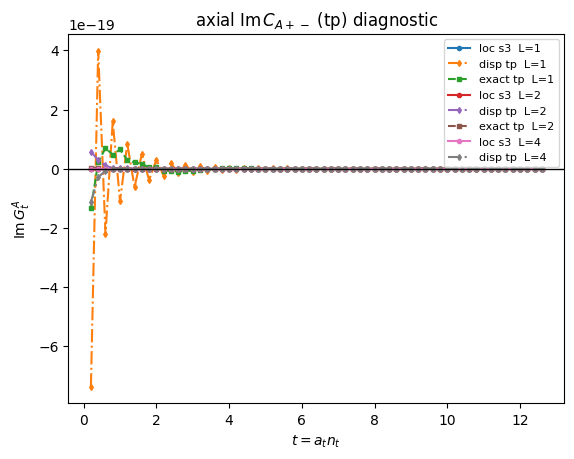

In [13]:
# Im DIAGNOSTIC: C_{A+-} is a single complex channel (not self-reflection-even).  Plot Im(G_t) for the
# three estimators, L=1,2.  Free massless even-Nf: expect Im consistent with noise/cutoff (see
# jj_reality_tsymmetry_claude.md); a stable nonzero Im flags a genuine axial phase or a source/sink asymmetry.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft
plt.figure()
def loc_Gt_im(L):  cd='corr_deter_local_axial_%sL%d'%(tag,L); return load_Apm(cd,'s3').imag
def disp_Gt_im(L): return load_Apm('corr_deter_disp_axial_%sL%d'%(tag,L),'tp').imag
def ex_Gt_im(L):   return load_Apm('corr_deter_exact1_axial_%sL%d'%(tag,L),'tp').imag
for L in [1, 2, 4]:
    try: plt.plot(t, loc_Gt_im(L)[dt], 'o-', ms=3, label='loc s3  L=%d' % L)
    except (OSError, KeyError): pass
    try: plt.plot(t, disp_Gt_im(L)[dt], 'd-.', ms=3, label='disp tp  L=%d' % L)
    except (OSError, KeyError): pass
    try: plt.plot(t, ex_Gt_im(L)[dt], 's--', ms=3, label='exact tp  L=%d' % L)
    except (OSError, KeyError): pass
plt.axhline(0.0, color='k', lw=1)
plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$\mathrm{Im}\,G_t^A$')
plt.title(r'axial $\mathrm{Im}\,C_{A+-}$ (tp) diagnostic'); plt.legend(fontsize=8)
plt.savefig('comp_trio_axial_im_tp.pdf', bbox_inches='tight')